Student Details:-
Name: Mohd Nizam Mohd Nasir Shaikh;
Student ID: 24198170;
Student email: X24198170@student.ncirl.ie.

Project information:-
Professor: Mr. Eric Gyamfi;
Module: Programming for Financial Data Science;
Project: 70%.

In [1]:
# B.1. Exploratory Data Analysis(EDA)

In [2]:
# Imported necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [3]:
# Uploaded the crime offence dataset as dataframe(df) 
df = pd.read_csv("Crime offense.csv")

In [4]:
# Inspecting the dataset structure to understand features
df.shape

(25920, 10)

In [5]:
df.dtypes

STATISTIC           object
Statistic Label     object
TLIST(Q1)            int64
Quarter             object
C02479V04377         int64
Garda Region        object
C02480V03003        object
Type of Offence     object
UNIT                object
VALUE              float64
dtype: object

In [6]:
df.head()

,STATISTIC,Statistic Label,TLIST(Q1),Quarter,C02479V04377,Garda Region,C02480V03003,Type of Offence,UNIT,VALUE
0,CJQ05,Recorded crime incidents,20031,2003Q1,10,10 Dublin Metropolitan Region,1,Homicide & related offences (01),Number,7.0
1,CJQ05,Recorded crime incidents,20031,2003Q1,10,10 Dublin Metropolitan Region,111,Murder (0111),Number,4.0
2,CJQ05,Recorded crime incidents,20031,2003Q1,10,10 Dublin Metropolitan Region,112,Manslaughter (0112),Number,2.0
3,CJQ05,Recorded crime incidents,20031,2003Q1,10,10 Dublin Metropolitan Region,113,Infanticide (0113),Number,0.0
4,CJQ05,Recorded crime incidents,20031,2003Q1,10,10 Dublin Metropolitan Region,12,Dangerous driving leading to death (012),Number,1.0


In [7]:
df.describe()

,TLIST(Q1),C02479V04377,VALUE
count,25920.000000,25920.000000,25872.000000
mean,20140.033333,25.000000,412.008619
std,64.956357,11.180556,900.306919
min,20031.000000,10.000000,0.000000
25%,20083.000000,17.500000,4.000000
50%,20141.500000,25.000000,31.000000
75%,20194.000000,32.500000,401.000000
max,20252.000000,40.000000,10475.000000


In [8]:
#B.2. Missing values 

In [9]:
# Checking, cleaning and imputing nulls with median
df.isnull().sum()

STATISTIC           0
Statistic Label     0
TLIST(Q1)           0
Quarter             0
C02479V04377        0
Garda Region        0
C02480V03003        0
Type of Offence     0
UNIT                0
VALUE              48
dtype: int64

In [10]:
df["VALUE"] = df["VALUE"].fillna(df["VALUE"].median())

In [11]:
df.isnull().sum()

STATISTIC          0
Statistic Label    0
TLIST(Q1)          0
Quarter            0
C02479V04377       0
Garda Region       0
C02480V03003       0
Type of Offence    0
UNIT               0
VALUE              0
dtype: int64

In [12]:
# Dropping below columns which not required for ML model
df = df.drop(columns =["STATISTIC", "Statistic Label", "TLIST(Q1)", "C02479V04377","C02480V03003", "UNIT"], axis=1)

In [13]:
df.head()

,Quarter,Garda Region,Type of Offence,VALUE
0,2003Q1,10 Dublin Metropolitan Region,Homicide & related offences (01),7.0
1,2003Q1,10 Dublin Metropolitan Region,Murder (0111),4.0
2,2003Q1,10 Dublin Metropolitan Region,Manslaughter (0112),2.0
3,2003Q1,10 Dublin Metropolitan Region,Infanticide (0113),0.0
4,2003Q1,10 Dublin Metropolitan Region,Dangerous driving leading to death (012),1.0


In [14]:
df.dtypes

Quarter             object
Garda Region        object
Type of Offence     object
VALUE              float64
dtype: object

In [15]:
# Visualization 1:
# Total incidents by Quarter for crime time series visualization & trend analysis
Crime_time_series = df.groupby("Quarter")["VALUE"].sum().reset_index()

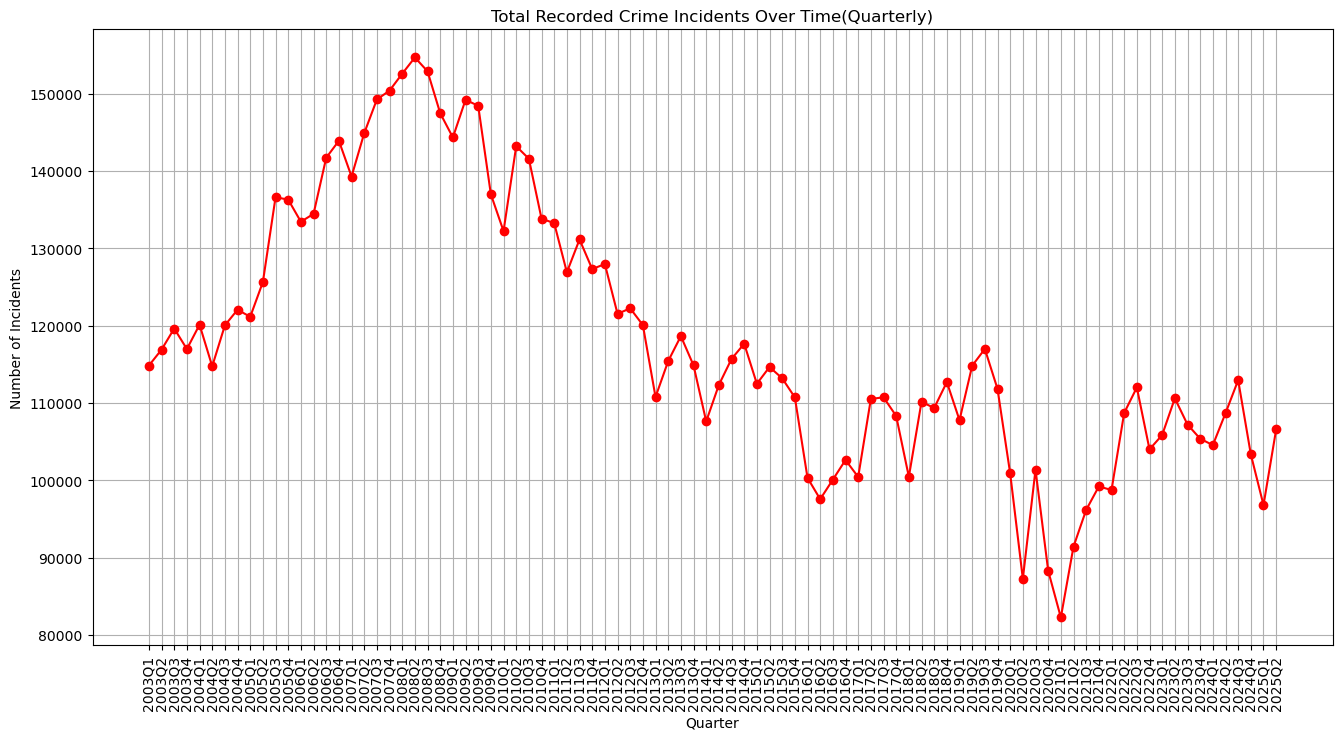

In [16]:
# Plotting code of Line Graph
plt.figure(figsize=(16,8))
plt.plot(Crime_time_series["Quarter"], Crime_time_series["VALUE"], marker="o", linestyle="-", color="red")
plt.title("Total Recorded Crime Incidents Over Time(Quarterly)")
plt.xlabel("Quarter")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

In [17]:
# Visualization 2:
# Recorded crime rates by Garda Region 
region_counts = df.groupby("Garda Region")["VALUE"].sum().sort_values(ascending=False)

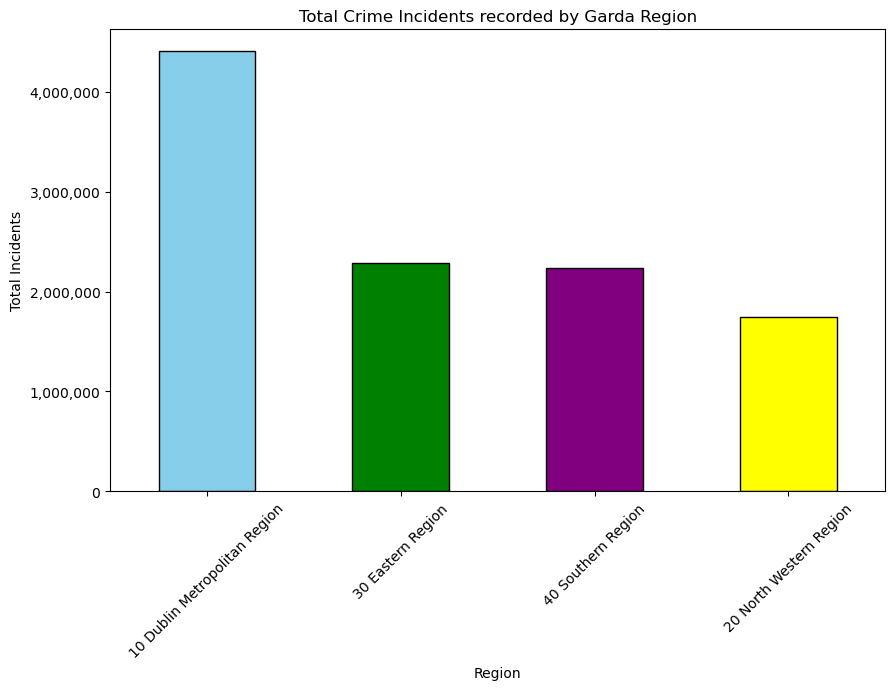

In [18]:
# Plotting code of Bar Graph 
plt.figure(figsize=(10, 6))
bar_colors = ["skyblue", "green", "purple", "yellow"]
ax = region_counts.plot(kind="bar", color=bar_colors, edgecolor="black")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.title("Total Crime Incidents recorded by Garda Region")
plt.xlabel("Region")
plt.ylabel("Total Incidents")
plt.xticks(rotation=45)
plt.show()

In [19]:
# Splitting the Quarter feature for 3rd Visualization
df["Year"] = df["Quarter"].str[:4].astype(int)
df["Qtr Num"] = df["Quarter"].str[-1].astype(int)

In [20]:
df.tail()

,Quarter,Garda Region,Type of Offence,VALUE,Year,Qtr Num
25915,2025Q2,40 Southern Region,"Offences against government, justice procedure...",578.0,2025,2
25916,2025Q2,40 Southern Region,Offences against government and its agents (151),18.0,2025,2
25917,2025Q2,40 Southern Region,Organisation of crime and conspiracy to commit...,0.0,2025,2
25918,2025Q2,40 Southern Region,Perverting the course of justice (153),3.0,2025,2
25919,2025Q2,40 Southern Region,"Offences while in custody, breach of court ord...",557.0,2025,2


In [21]:
# Visualization 3:
# Demonstrating incidents by 4 Quarters
df_season = df.groupby(["Year", "Qtr Num"])["VALUE"].sum().reset_index()

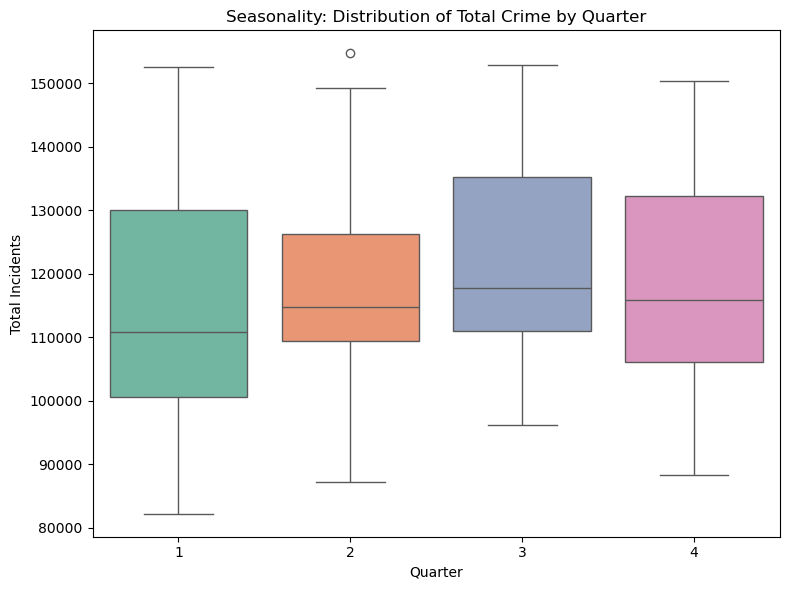

In [22]:
# Plotting code for Box Plot chart
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_season, x="Qtr Num", y="VALUE", hue="Qtr Num", legend=False, palette="Set2")
plt.title("Seasonality: Distribution of Total Crime by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Total Incidents")
plt.tight_layout()
plt.show()

In [23]:
# Splitting Garda Region into Region & Region code
df["Region Code"] = df["Garda Region"].str[:2].astype(int)
df["Region"] = df["Garda Region"].str[3:]

In [24]:
# Visualization 4:
# Illustrating Incidents by Year & Region
df_heatmap = df.groupby(["Year", "Region"])["VALUE"].sum().reset_index()
heatmap_data = df_heatmap.pivot(index="Region", columns="Year", values="VALUE")

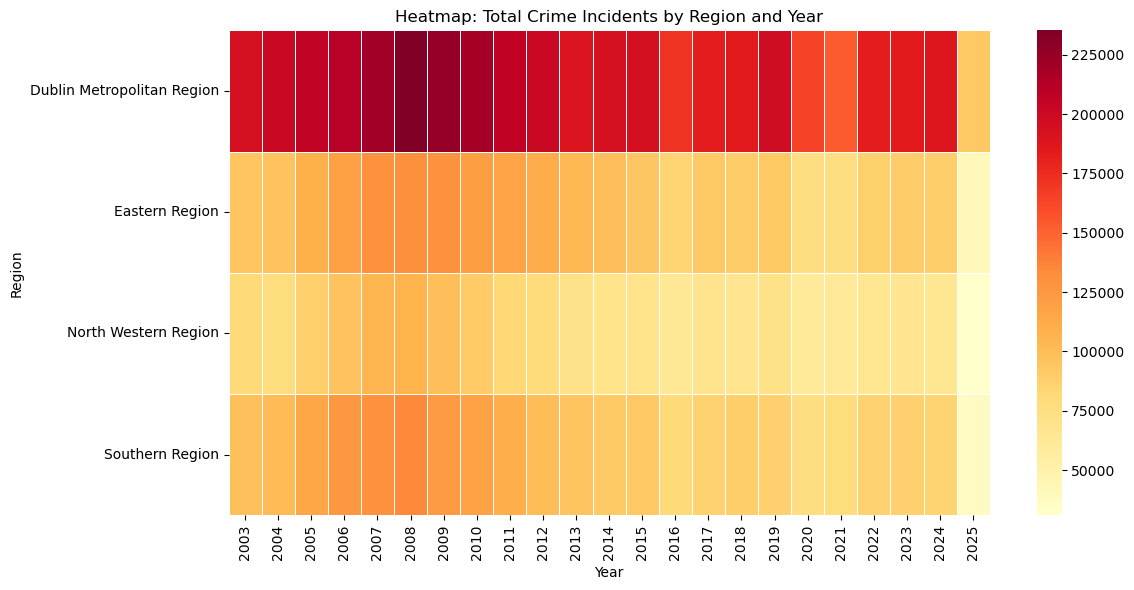

In [25]:
# Plotting code of Heatmap chart
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot= False, cmap="YlOrRd", linewidths=.5)
plt.title("Heatmap: Total Crime Incidents by Region and Year")
plt.xlabel("Year")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

In [26]:
# Splitting the Type of Offence feature into Offence & their Offence Section 
split_offence = df["Type of Offence"].str.rsplit("(", n=1)
df["Offence"] = split_offence.str[0]
df["Offence Section"] = split_offence.str[1].str.replace(")", "",regex=False).str.strip()

In [27]:
df.head()

,Quarter,Garda Region,Type of Offence,VALUE,Year,Qtr Num,Region Code,Region,Offence,Offence Section
0,2003Q1,10 Dublin Metropolitan Region,Homicide & related offences (01),7.0,2003,1,10,Dublin Metropolitan Region,Homicide & related offences,01
1,2003Q1,10 Dublin Metropolitan Region,Murder (0111),4.0,2003,1,10,Dublin Metropolitan Region,Murder,0111
2,2003Q1,10 Dublin Metropolitan Region,Manslaughter (0112),2.0,2003,1,10,Dublin Metropolitan Region,Manslaughter,0112
3,2003Q1,10 Dublin Metropolitan Region,Infanticide (0113),0.0,2003,1,10,Dublin Metropolitan Region,Infanticide,0113
4,2003Q1,10 Dublin Metropolitan Region,Dangerous driving leading to death (012),1.0,2003,1,10,Dublin Metropolitan Region,Dangerous driving leading to death,012


In [28]:
# Dropping more features to train ML efficiently
df = df.drop(columns = ["Quarter", "Garda Region", "Type of Offence", "Region Code","Offence Section"], axis=1)

In [29]:
df.tail()

,VALUE,Year,Qtr Num,Region,Offence
25915,578.0,2025,2,Southern Region,"Offences against government, justice procedure..."
25916,18.0,2025,2,Southern Region,Offences against government and its agents
25917,0.0,2025,2,Southern Region,Organisation of crime and conspiracy to commit...
25918,3.0,2025,2,Southern Region,Perverting the course of justice
25919,557.0,2025,2,Southern Region,"Offences while in custody, breach of court ord..."


In [30]:
#B.3. Feature Engineering

In [31]:
# Imported Libraries to alter features of categorical into numerical data    
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

In [32]:
# One-Hot Encoding
df = pd.get_dummies(df, columns = ["Region"], dtype=int)

In [33]:
# Label Encoding
le_Offence = LabelEncoder()
df["Offence"] = le_Offence.fit_transform(df["Offence"])

In [34]:
df.sample(5)

,VALUE,Year,Qtr Num,Offence,Region_Dublin Metropolitan Region,Region_Eastern Region,Region_North Western Region,Region_Southern Region
5278,0.0,2007,3,25,0,0,1,0
15788,24.0,2016,3,0,0,0,0,1
10419,10.0,2012,1,24,1,0,0,0
13759,4.0,2014,4,47,0,0,0,1
817,2.0,2003,3,26,0,0,0,1


In [35]:
#B.4. Standardization Scaling

In [36]:
# Libraries for StandardScaling & training + testing the features - label
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [37]:
# X - Feature & y - variable
X = df[["Year", "Qtr Num", "Offence", "Region_Dublin Metropolitan Region","Region_Eastern Region","Region_North Western Region","Region_Southern Region"]]
y = df["VALUE"]

In [38]:
# Scaling
scaler = StandardScaler()

In [39]:
# Training & testing with 80% - 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
# Transformed train and test scale variable
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
scaler.fit(X_train)

StandardScaler()

In [42]:
df.sample(5)

,VALUE,Year,Qtr Num,Offence,Region_Dublin Metropolitan Region,Region_Eastern Region,Region_North Western Region,Region_Southern Region
5029,2590.0,2007,2,18,0,0,1,0
17609,2820.0,2018,2,66,1,0,0,0
4292,773.0,2006,3,10,0,0,0,1
8656,715.0,2010,3,19,1,0,0,0
15938,0.0,2016,4,1,0,0,1,0


In [43]:
#C.1. Traditional model

In [44]:
# Imported Library for Decision Tree Regressor model
from sklearn.tree import DecisionTreeRegressor

In [45]:
# Codes for model training
dt_model = DecisionTreeRegressor(max_depth=8,random_state=42)
dt_model.fit(X_train_scaled, y_train)

DecisionTreeRegressor(max_depth=8, random_state=42)

In [46]:
# Predicting model 
dt_preds = dt_model.predict(X_test_scaled)

In [47]:
#C.2. Advanced Model

In [48]:
# Imported library for Random Forest Regressor model
from sklearn.ensemble import RandomForestRegressor

In [49]:
# Codes to train model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [50]:
# Predicting model 
rf_preds = rf_model.predict(X_test_scaled)

In [51]:
#D.1. Metrics - Root mean squared error(RMSE) & R-Squared(R2) 

In [52]:
# Imported RMSE+R2 metrics library 
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [53]:
# Assigned rmse metric to test & predict DTR model
# RMSE accuracy for DTR is high(non-efficient)
dt_rmse = mean_squared_error(y_test, dt_preds)**0.5
print(f"RMSE for Decision Tree Regressor: {dt_rmse:.2f}")

RMSE for Decision Tree Regressor: 315.32


In [54]:
# Assigned R2 metric to test & predict DTR model
# R2 accuracy is low score
dt_r2 = r2_score(y_test, dt_preds)
print(f"R2 Score for Decision Tree Regressor: {dt_r2:.4f}")

R2 Score for Decision Tree Regressor: 0.8830


In [55]:
# Assigned rmse metric to test & predict RF model
# RMSE accuracy for RF is low(efficient)
rf_rmse = mean_squared_error(y_test, rf_preds)**0.5
print(f"RMSE for Random Forest: {rf_rmse:.2f}")

RMSE for Random Forest: 78.72


In [56]:
# Assigned R2 metric to test &predict RF model
# R2 accuracy is high score
rf_r2 = r2_score(y_test, rf_preds)
print(f"R2 Score for Random Forest: {rf_r2:.4f}")

R2 Score for Random Forest: 0.9927


(: THANK YOU :)